<div style="color:#3c4d5a; border-top:7px solid #42A5F5; border-bottom:7px solid #42A5F5; padding:8px; text-align:center; text-transform:uppercase">
  <h1>STREAMML - PREDICCION DE NUEVOS EJEMPLOS</h1>
</div>

<strong>Proyecto:</strong> StreamML  | 
  <strong>Integrantes:</strong> Alexis Guaman y Cinthya Ramon  | 
  <strong>Modalidad:</strong> Machine Learning offline

<div id="objetivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Objetivo del notebook</h2> </div>

Este notebook demuestra como consumir los dos modelos oficiales sin reentrenarlos. El problema principal es garantizar que un ejemplo nuevo respete exactamente las variables, el orden y las unidades aprendidas; una prediccion numericamente valida puede ser incorrecta si el contrato se viola.

Al finalizar se obtienen perfiles reactivos, probabilidades predictivas y decisiones calculadas con el threshold persistido. Los ejemplos proceden de sesiones de test para conservar la clase real como referencia y permitir una interpretacion verificable.

<div id="requisitos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Requisitos, entradas y alcance real</h2> </div>

Se requieren Python 3.11, pandas, NumPy, joblib y Matplotlib, ademas de los dos modelos, contratos y threshold guardados en `models/registry/`. Los datasets procesados aportan ejemplos de test con clase real conocida; no se usan para volver a ajustar los estimadores.

El reactivo acepta `upload_mbps`, `download_mbps` y `latency_ms`. El predictivo recibe 19 estadisticas de 600 segundos historicos y estima una etiqueta para los 600 segundos posteriores. Sus clases son exclusivamente `maintain` y `downgrade_needed`.

Jitter, perdida de paquetes, clase `critical`, horizontes en minutos y decisiones de agente no estan soportados por los artefactos actuales. Se documentan como limitaciones para impedir que una demostracion offline se confunda con funcionalidad implementada.

<div id="contenido" style="color:#106ba3"><h3>Contenido</h3> </div>

- [Objetivo](#objetivo)
- [Fundamentos metodologicos](#fundamentos-metodologicos)
- [Fase 1: Entorno, modelos y contratos](#fase-1-entorno-modelos-y-contratos)
- [Fase 2: Validacion del orden de variables](#fase-2-validacion-del-orden-de-variables)
- [Fase 3: Ejemplos reactivos](#fase-3-ejemplos-reactivos)
- [Fase 4: Interpretacion reactiva](#fase-4-interpretacion-reactiva)
- [Fase 5: Ejemplo temporal predictivo](#fase-5-ejemplo-temporal-predictivo)
- [Fase 6: Probabilidades, threshold y prediccion](#fase-6-probabilidades-threshold-y-prediccion)
- [Fase 7: Interpretacion final](#fase-7-interpretacion-final)
- [Conclusiones](#conclusiones)
- [Referencias](#referencias)

<div id="fundamentos-metodologicos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fundamentos metodologicos</h2> </div>

`predict_proba` devuelve una distribucion de probabilidad sobre las clases conocidas por el estimador. En el reactivo, la clase de mayor probabilidad se presenta como perfil recomendado. Estas probabilidades expresan confianza relativa del modelo, no una garantia sobre el comportamiento futuro de la red.

El predictivo utiliza una regla adicional: compara la probabilidad positiva con el threshold seleccionado durante validacion. Mantener ese valor fuera del codigo de la demostracion evita ajustarlo a conveniencia despues de observar test y hace que notebook, script y GUI apliquen la misma politica.

<div id="fase-1-entorno-modelos-y-contratos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 1: Entorno, modelos y contratos</h2> </div>

Se localiza la raiz mediante rutas relativas y se cargan los dos `model.joblib` desde `models/registry/`. Junto a ellos se leen contratos, threshold y manifiesto de entrenamiento. Los datasets procesados se utilizan unicamente para seleccionar ejemplos reproducibles con target conocido.

Separar carga de inferencia y entrenamiento evita modificar los modelos por accidente. La celda informa las clases de estimador realmente deserializadas para que la documentacion no atribuya una arquitectura distinta al artefacto.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
print("Proyecto:", ROOT.name)

import joblib

release_dir = ROOT / "models" / "registry"
reactive_model = joblib.load(release_dir / "reactive" / "model.joblib")
predictive_model = joblib.load(release_dir / "predictive" / "model.joblib")
reactive_contract = json.loads((release_dir / "reactive" / "feature_contract.json").read_text(encoding="utf-8"))
predictive_contract = json.loads((release_dir / "predictive" / "feature_contract.json").read_text(encoding="utf-8"))
predictive_manifest = json.loads((release_dir / "predictive" / "training_manifest.json").read_text(encoding="utf-8"))
threshold = json.loads((release_dir / "predictive" / "threshold.json").read_text(encoding="utf-8"))["threshold"]
print("Reactive:", type(reactive_model).__name__)
print("Predictive:", type(predictive_model).__name__)

Proyecto: Adaptive-Streaming-ai


Reactive: DecisionTreeClassifier
Predictive: Pipeline


<div id="fase-2-validacion-del-orden-de-variables" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 2: Validacion del orden de variables</h2> </div>

Scikit-learn conserva los nombres de columnas observados durante el ajuste. Se comparan con las listas del contrato y se exige coincidencia exacta, incluyendo posicion. Esto detecta columnas omitidas, adicionales o intercambiadas antes de llamar a `predict_proba`.

Para el predictivo tambien se comprueba que ninguna columna futura o target aparezca entre las 19 entradas. La tabla de posiciones funciona como especificacion visible para construir posteriormente un CSV o una integracion de telemetria compatible.

In [2]:
reactive_features = reactive_contract["features"]
predictive_features = predictive_contract["features"]
assert len(reactive_features) == 3
assert len(predictive_features) == 19
assert list(reactive_model.feature_names_in_) == reactive_features
assert list(predictive_model.feature_names_in_) == predictive_features
assert not set(predictive_features).intersection(predictive_contract["forbidden_input_columns"])
display(pd.DataFrame({"position": range(1, 20), "predictive_feature": predictive_features}))

,position,predictive_feature
0,1,throughput_mean
1,2,throughput_median
2,3,throughput_min
3,4,throughput_max
4,5,throughput_std
5,6,throughput_p10
6,7,throughput_p25
7,8,throughput_first
8,9,throughput_last
9,10,throughput_change


<div id="fase-3-ejemplos-reactivos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 3: Ejemplos reactivos</h2> </div>

Se selecciona una medicion real de test por cada clase disponible. Esto produce ejemplos asociados a condiciones que el target considera adecuadas para `low`, `medium` y `high`, sin crear manualmente velocidades o latencias que pudieran quedar fuera de la distribucion observada.

Cada fila conserva variables, clase real, prediccion y probabilidad por perfil. El ejemplo permite comprobar tanto el formato esperado como la respuesta del modelo ante casos que no formaron parte del ajuste.

In [3]:
reactive_data = pd.read_csv(ROOT / "data" / "processed" / "reactive_dataset.csv")
reactive_examples = reactive_data.loc[reactive_data["split"] == "test"].groupby("target", group_keys=False).head(1).copy()
reactive_x = reactive_examples.loc[:, reactive_features]
assert list(reactive_x.columns) == reactive_features

reactive_probabilities = reactive_model.predict_proba(reactive_x)
reactive_predictions = reactive_model.predict(reactive_x)
reactive_results = reactive_examples[["session_id", "target", *reactive_features]].copy()
reactive_results["prediction"] = reactive_predictions
for index, label in enumerate(reactive_model.classes_):
    reactive_results[f"prob_{label}"] = reactive_probabilities[:, index]
reactive_results["ok"] = reactive_results["target"] == reactive_results["prediction"]
display(reactive_results)

,session_id,target,upload_mbps,download_mbps,latency_ms,prediction,prob_high,prob_low,prob_medium,ok
21349,O1d7ee6cb-28c6-4c5a-b3a6-7df8707dc9fb,high,22.8180,24.0640,26.0000,high,1.0000,0.0000,0.0000,True
21350,O6b9bbdbb-5374-4319-96fd-117b2cc9db4b,low,2.2890,47.5930,30.0000,low,0.0000,1.0000,0.0000,True
21363,O9c8634c4-3347-4644-b44a-13903c4bbfd7,medium,4.6650,0.2880,98.0000,medium,0.0000,0.0000,1.0000,True


<div id="fase-4-interpretacion-reactiva" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 4: Interpretacion reactiva</h2> </div>

La recomendacion corresponde a la clase con probabilidad maxima. La confianza mostrada ayuda a distinguir una decision clara de otra cercana entre perfiles, mientras `ok` compara la salida con la pseudoetiqueta real del dataset.

Una recomendacion `high` significa que las variables actuales se parecen a mediciones etiquetadas para ese perfil; no garantiza estabilidad futura. Para una decision preventiva debe considerarse por separado la salida predictiva y, en una etapa posterior, una politica de control documentada.

In [4]:
for row in reactive_results.itertuples(index=False):
    confidence = max(getattr(row, name) for name in reactive_results.columns if name.startswith("prob_"))
    print(f"Sesion {row.session_id}: real={row.target}, prediccion={row.prediction}, confianza={confidence:.4f}, correcto={row.ok}")

Sesion O1d7ee6cb-28c6-4c5a-b3a6-7df8707dc9fb: real=high, prediccion=high, confianza=1.0000, correcto=True
Sesion O6b9bbdbb-5374-4319-96fd-117b2cc9db4b: real=low, prediccion=low, confianza=1.0000, correcto=True
Sesion O9c8634c4-3347-4644-b44a-13903c4bbfd7: real=medium, prediccion=medium, confianza=1.0000, correcto=True


<div id="fase-5-ejemplo-temporal-predictivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 5: Ejemplo temporal predictivo</h2> </div>

El ejemplo temporal procede de una sesion reservada para test. Sus 19 entradas resumen 600 segundos de capacidad historica mediante medias, percentiles, extremos, tendencia y proporciones bajo capacidades requeridas. El modelo no recibe las columnas del horizonte futuro.

El contexto temporal muestra donde termina el historial y donde empieza el intervalo de 600 segundos que define la clase real. Esta separacion permite evaluar la prediccion sin confundir evidencia disponible con informacion posterior.

In [5]:
predictive_data = pd.read_csv(ROOT / "data" / "processed" / "predictive_dataset.csv")
test_sessions = set(predictive_manifest["splits"]["test"])
predictive_example = predictive_data.loc[predictive_data["session_id"].isin(test_sessions)].iloc[[0]].copy()
predictive_x = predictive_example.loc[:, predictive_features]
assert list(predictive_x.columns) == predictive_features
assert predictive_x.notna().all().all()

temporal_context = predictive_example[["session_id", "window_id", "window_start_seconds", "window_end_seconds", "future_window_start_seconds", "future_window_end_seconds", "current_profile", "target"]]
display(temporal_context)
display(predictive_x.T.rename(columns={predictive_x.index[0]: "value"}))

,session_id,window_id,window_start_seconds,window_end_seconds,future_window_start_seconds,future_window_end_seconds,current_profile,target
0,run_4191,run_4191_w000000,0.0000,600.0000,600.0000,1200.0000,2,maintain


,value
throughput_mean,25.0000
throughput_median,25.0000
throughput_min,25.0000
throughput_max,25.0000
throughput_std,0.0000
throughput_p10,25.0000
throughput_p25,25.0000
throughput_first,25.0000
throughput_last,25.0000
throughput_change,0.0000


<div id="fase-6-probabilidades-threshold-y-prediccion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 6: Probabilidades, threshold y prediccion</h2> </div>

Se extraen las probabilidades de `maintain` y `downgrade_needed` respetando el orden interno de clases. La segunda se compara con el threshold guardado; si lo alcanza, la decision es reducir, y en caso contrario mantener.

El grafico hace visible la relacion entre ambas probabilidades y el umbral. El valor no se optimiza en este notebook: modificarlo con base en el acierto del ejemplo constituiria seleccion sobre test.

,session_id,window_id,prob_maintain,prob_downgrade_needed,threshold,prediction,target,ok
0,run_4191,run_4191_w000000,0.9993,0.0007,0.5000,maintain,maintain,True


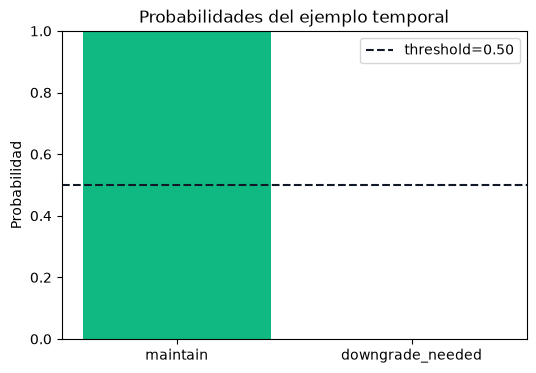

In [6]:
predictive_proba = predictive_model.predict_proba(predictive_x)[0]
class_to_index = {int(label): index for index, label in enumerate(predictive_model.classes_)}
prob_maintain = float(predictive_proba[class_to_index[0]])
prob_downgrade = float(predictive_proba[class_to_index[1]])
prediction = "downgrade_needed" if prob_downgrade >= threshold else "maintain"
real_target = str(predictive_example["target"].iloc[0])

predictive_result = pd.DataFrame([{
    "session_id": predictive_example["session_id"].iloc[0],
    "window_id": predictive_example["window_id"].iloc[0],
    "prob_maintain": prob_maintain,
    "prob_downgrade_needed": prob_downgrade,
    "threshold": threshold,
    "prediction": prediction,
    "target": real_target,
    "ok": prediction == real_target,
}])
display(predictive_result)

plt.figure(figsize=(6, 4))
plt.bar(["maintain", "downgrade_needed"], [prob_maintain, prob_downgrade], color=["#10b981", "#dc2626"])
plt.axhline(threshold, color="#111827", linestyle="--", label=f"threshold={threshold:.2f}")
plt.ylim(0, 1)
plt.ylabel("Probabilidad")
plt.title("Probabilidades del ejemplo temporal")
plt.legend()
plt.show()

<div id="fase-7-interpretacion-final" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 7: Interpretacion final</h2> </div>

La explicacion se construye con tres elementos observables: probabilidad positiva, threshold y target real. Esto permite rastrear por que se emitio una clase y verificar si coincidio con el resultado etiquetado.

La salida predictiva no indica directamente `low`, `medium` o `high`. Solo informa si el perfil actual parece sostenible dentro del horizonte contractual. Combinar ambas salidas requiere una politica de control separada que aun no forma parte de esta publicacion.

In [7]:
relation = "supera o iguala" if prob_downgrade >= threshold else "no alcanza"
print(
    f"La probabilidad de reduccion ({prob_downgrade:.4f}) {relation} el threshold ({threshold:.4f}); "
    f"por eso la prediccion es {prediction}. Target real: {real_target}. Acierto: {prediction == real_target}."
)

La probabilidad de reduccion (0.0007) no alcanza el threshold (0.5000); por eso la prediccion es maintain. Target real: maintain. Acierto: True.


<div style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Ejemplos prácticos por clase predictiva</h2></div>

Se busca automaticamente una ventana real de cada clase predictiva dentro de las sesiones de test. Si una clase no estuviera presente, el notebook lo informaria en lugar de fabricar un caso. Para cada ventana se calculan probabilidades, decision por threshold y acierto.

La comparacion lado a lado muestra como cambia la evidencia del modelo entre mantenimiento y reduccion. Es un ejemplo de uso del clasificador, no una simulacion de varios minutos ni una decision completa del sistema de streaming.

,session_id,window_id,current_profile,target,prob_maintain,prob_downgrade_needed,prediction,ok
0,run_4191,run_4191_w000000,2,maintain,0.9993,0.0007,maintain,True
545,run_4686,run_4686_w000000,1,downgrade_needed,0.0005,0.9995,downgrade_needed,True


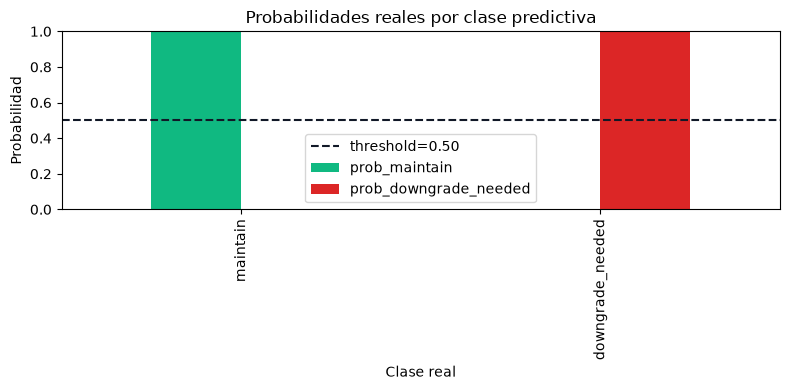

In [8]:
predictive_examples = (
    predictive_data.loc[predictive_data["session_id"].isin(test_sessions)]
    .groupby("target", group_keys=False)
    .head(1)
    .copy()
)
missing_predictive_classes = sorted({"maintain", "downgrade_needed"} - set(predictive_examples["target"]))
if missing_predictive_classes:
    print("No existe un ejemplo de este tipo en el conjunto de prueba actual:", missing_predictive_classes)

predictive_examples_x = predictive_examples.loc[:, predictive_features]
example_probabilities = predictive_model.predict_proba(predictive_examples_x)
class_to_index = {int(label): index for index, label in enumerate(predictive_model.classes_)}
example_risk = example_probabilities[:, class_to_index[1]]
predictive_examples_results = predictive_examples[["session_id", "window_id", "current_profile", "target"]].copy()
predictive_examples_results["prob_maintain"] = example_probabilities[:, class_to_index[0]]
predictive_examples_results["prob_downgrade_needed"] = example_risk
predictive_examples_results["prediction"] = np.where(example_risk >= threshold, "downgrade_needed", "maintain")
predictive_examples_results["ok"] = predictive_examples_results["target"] == predictive_examples_results["prediction"]
display(predictive_examples_results)

predictive_examples_results.set_index("target")[["prob_maintain", "prob_downgrade_needed"]].plot.bar(
    figsize=(8, 4), color=["#10b981", "#dc2626"]
)
plt.axhline(threshold, color="#111827", linestyle="--", label=f"threshold={threshold:.2f}")
plt.title("Probabilidades reales por clase predictiva")
plt.xlabel("Clase real")
plt.ylabel("Probabilidad")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

<div style="color:#106ba3"><h3>Como interpretar las salidas y su alcance</h3> </div>

Una probabilidad alta de `downgrade_needed` significa que el resumen historico se parece a ventanas cuyo horizonte posterior presento condiciones que activaron la etiqueta de reduccion. Una probabilidad inferior al threshold produce `maintain`; ninguna de las dos clases equivale por si sola a una orden sobre OBS.

El contrato no incluye `critical`, jitter, perdida de paquetes ni horizontes de 5, 10, 20 o 30 minutos. Tampoco existe un agente autonomo activo. Implementar esos casos exige datos reales, nuevas etiquetas y una politica probada; agregarlos solo como texto o reglas manuales seria enganoso.

<div style="color:#106ba3"><h3>Formulario reactivo (escenario manual de demostración)</h3> </div>

Las variables de esta celda pueden modificarse libremente para explorar cómo el modelo reactivo responde a distintas condiciones de red. Los valores no provienen del conjunto de prueba; están claramente marcados como escenario manual.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# FORMULARIO REACTIVO — Edite los valores para obtener una nueva predicción
# ══════════════════════════════════════════════════════════════════════════════
# Variables de entrada del modelo reactivo (valores editables):
upload_mbps_form   = 10.0   # Throughput de subida en Mbps
download_mbps_form = 30.0   # Throughput de bajada en Mbps
latency_ms_form    = 25.0   # Latencia en ms

# Construcción del ejemplo
X_form = pd.DataFrame([[upload_mbps_form, download_mbps_form, latency_ms_form]],
                       columns=reactive_contract["features"])
prob_form   = reactive_model.predict_proba(X_form)[0]
pred_form   = reactive_model.predict(X_form)[0]
classes_form = list(reactive_model.classes_)

print("── Predicción reactiva (formulario manual) ──────────────────────────────────")
print(f"  upload_mbps   : {upload_mbps_form} Mbps")
print(f"  download_mbps : {download_mbps_form} Mbps")
print(f"  latency_ms    : {latency_ms_form} ms")
print()
for cls, p in zip(classes_form, prob_form):
    print(f"  P({cls}) = {p:.4f}")
print()
print(f"  Predicción: {pred_form.upper()}")

display(pd.DataFrame({
    "variable": reactive_contract["features"],
    "valor": [upload_mbps_form, download_mbps_form, latency_ms_form],
    "unidad": ["Mbps", "Mbps", "ms"],
}))


── Predicción reactiva (formulario manual) ──────────────────────────────────
  upload_mbps   : 10.0 Mbps
  download_mbps : 30.0 Mbps
  latency_ms    : 25.0 ms

  P(high) = 1.0000
  P(low) = 0.0000
  P(medium) = 0.0000

  Predicción: HIGH


,variable,valor,unidad
0,upload_mbps,10.0000,Mbps
1,download_mbps,30.0000,Mbps
2,latency_ms,25.0000,ms


<div style="color:#106ba3"><h3>Escenarios manuales de demostración</h3> </div>

Los tres escenarios siguientes **no provienen de datos reales**. Están construidos manualmente para ilustrar cómo responde el modelo predictivo ante condiciones de red bien definidas: estable (alto throughput constante), riesgo (bajo throughput decreciente) y límite (throughput exactamente en el umbral del perfil actual).

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# ESCENARIOS MANUALES DE DEMOSTRACIÓN — Predictivo
# ══════════════════════════════════════════════════════════════════════════════
# Estos escenarios son ilustrativos y NO provienen de datos reales.
# Están construidos manualmente para demostrar el comportamiento del modelo
# en condiciones extremas bien definidas.

_scenarios = [
    {
        "nombre": "Estable",
        "descripcion": "Throughput alto y constante durante 600 s",
        # Valores coherentes con una sesión de alta capacidad
        "throughput_mean": 8.0, "throughput_median": 8.0, "throughput_min": 7.5,
        "throughput_max": 8.5, "throughput_std": 0.1, "throughput_p10": 7.6,
        "throughput_p25": 7.8, "throughput_first": 8.0, "throughput_last": 8.0,
        "throughput_change": 0.0, "throughput_slope": 0.0,
        "throughput_coefficient_variation": 0.012, "measurements_count": 600,
        "lookback_duration_seconds": 600, "proportion_below_low": 0.0,
        "proportion_below_medium": 0.0, "proportion_below_high": 0.0,
        "current_profile": 3, "required_capacity_mbps": 6.75,
    },
    {
        "nombre": "Riesgo",
        "descripcion": "Throughput bajo y decreciente, alta variabilidad",
        "throughput_mean": 1.0, "throughput_median": 0.9, "throughput_min": 0.3,
        "throughput_max": 1.8, "throughput_std": 0.4, "throughput_p10": 0.4,
        "throughput_p25": 0.6, "throughput_first": 1.5, "throughput_last": 0.5,
        "throughput_change": -1.0, "throughput_slope": -0.008,
        "throughput_coefficient_variation": 0.4, "measurements_count": 600,
        "lookback_duration_seconds": 600, "proportion_below_low": 0.5,
        "proportion_below_medium": 0.9, "proportion_below_high": 1.0,
        "current_profile": 2, "required_capacity_mbps": 3.375,
    },
    {
        "nombre": "Límite",
        "descripcion": "Throughput exactamente en el umbral del perfil actual",
        "throughput_mean": 3.375, "throughput_median": 3.375, "throughput_min": 3.0,
        "throughput_max": 3.8, "throughput_std": 0.15, "throughput_p10": 3.1,
        "throughput_p25": 3.2, "throughput_first": 3.4, "throughput_last": 3.3,
        "throughput_change": -0.1, "throughput_slope": -0.001,
        "throughput_coefficient_variation": 0.044, "measurements_count": 600,
        "lookback_duration_seconds": 600, "proportion_below_low": 0.0,
        "proportion_below_medium": 0.5, "proportion_below_high": 1.0,
        "current_profile": 2, "required_capacity_mbps": 3.375,
    },
]

_features_order = predictive_contract["features"]

print("── Escenarios manuales de demostración ──────────────────────────────────────")
for _sc in _scenarios:
    _nombre = _sc.pop("nombre")
    _desc   = _sc.pop("descripcion")
    _X_sc   = pd.DataFrame([_sc], columns=_features_order)
    _proba  = predictive_model.predict_proba(_X_sc)[0]
    _pos    = list(predictive_model.classes_).index(1)
    _prob_d = float(_proba[_pos])
    _pred_sc = "downgrade_needed" if _prob_d >= threshold else "maintain"
    _sc["nombre"] = _nombre
    _sc["descripcion"] = _desc
    print(f"  {_nombre} — {_desc}")
    print(f"    P(downgrade_needed) = {_prob_d:.4f}  |  threshold = {threshold}  |  predicción = {_pred_sc.upper()}")
    print()


── Escenarios manuales de demostración ──────────────────────────────────────
  Estable — Throughput alto y constante durante 600 s
    P(downgrade_needed) = 0.6608  |  threshold = 0.5  |  predicción = DOWNGRADE_NEEDED

  Riesgo — Throughput bajo y decreciente, alta variabilidad
    P(downgrade_needed) = 0.9990  |  threshold = 0.5  |  predicción = DOWNGRADE_NEEDED

  Límite — Throughput exactamente en el umbral del perfil actual
    P(downgrade_needed) = 0.9951  |  threshold = 0.5  |  predicción = DOWNGRADE_NEEDED



<div style="color:#106ba3"><h3>Predicción por lote</h3> </div>

La siguiente tabla muestra la predicción del modelo predictivo sobre cinco ejemplos reales tomados del conjunto de prueba. Incluye la probabilidad para cada clase, el threshold aplicado, la predicción resultante, el valor real y si el resultado fue correcto.

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# PREDICCIÓN POR LOTE — Dataset de prueba predictivo (5 ejemplos reales)
# ══════════════════════════════════════════════════════════════════════════════
from src.streamml.features.predictive_features import frame_in_contract_order, load_feature_contract

_pred_contract_obj = load_feature_contract(ROOT / "src" / "streamml" / "config" / "predictive_feature_contract.json")
_test_sessions_batch = set(predictive_manifest["splits"]["test"])
_pred_test_df = predictive_data.loc[predictive_data["session_id"].isin(_test_sessions_batch)].copy()

# Tomar los primeros 5 ejemplos de test
batch_sample = _pred_test_df.head(5).copy()
X_batch = frame_in_contract_order(batch_sample, _pred_contract_obj)
proba_batch = predictive_model.predict_proba(X_batch)
pos_idx_b = list(predictive_model.classes_).index(1)

prob_maintain_batch   = proba_batch[:, 1 - pos_idx_b]
prob_downgrade_batch  = proba_batch[:, pos_idx_b]
pred_batch            = ["downgrade_needed" if p >= threshold else "maintain"
                          for p in prob_downgrade_batch]
real_batch            = batch_sample["target"].tolist()
correct_batch         = [p == r for p, r in zip(pred_batch, real_batch)]

batch_result = pd.DataFrame({
    "session_id":             batch_sample["session_id"].tolist(),
    "P(maintain)":            [f"{p:.4f}" for p in prob_maintain_batch],
    "P(downgrade_needed)":    [f"{p:.4f}" for p in prob_downgrade_batch],
    "threshold":              threshold,
    "prediccion":             pred_batch,
    "real":                   real_batch,
    "correcto":               ["\u2713" if c else "\u2717" for c in correct_batch],
})

print("── Predicción por lote — 5 ejemplos del conjunto de test ─────────────────")
display(batch_result)
accuracy_batch = sum(correct_batch) / len(correct_batch)
print(f"  Exactitud en estos 5 ejemplos: {accuracy_batch:.0%}")


── Predicción por lote — 5 ejemplos del conjunto de test ─────────────────

,session_id,P(maintain),P(downgrade_needed),threshold,prediccion,real,correcto
0,run_4191,0.9993,0.0007,0.5000,maintain,maintain,✓
1,run_4191,0.9993,0.0007,0.5000,maintain,maintain,✓
2,run_4191,0.9993,0.0007,0.5000,maintain,maintain,✓
3,run_4191,0.9993,0.0007,0.5000,maintain,maintain,✓
4,run_4191,0.9993,0.0007,0.5000,maintain,maintain,✓


  Exactitud en estos 5 ejemplos: 100%


<div id="conclusiones" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Conclusiones</h2> </div>

Los ejemplos demuestran que ambos modelos pueden cargarse desde disco, validar sus entradas y producir probabilidades reproducibles. El reactivo devuelve recomendaciones para las tres clases disponibles y el predictivo aplica exactamente el threshold publicado a ejemplos reales de `maintain` y `downgrade_needed`.

Este notebook completa la cadena offline desde artefactos hasta inferencia interpretable, pero no representa todavia un controlador de streaming. Como mejora futura se necesita una fuente de telemetria compatible, validacion en sesiones operativas y una politica de agente con histeresis y limites de seguridad antes de automatizar cambios de perfil.

<div id="referencias" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Referencias y enlaces</h2> </div>

1. Contratos, manifiestos y metricas oficiales incluidos en este repositorio StreamML.
2. RTR-NetzTest Open Data, fuente del dataset reactivo.
3. YouTube Dataset on Mobile Streaming for Internet Traffic Modeling, Network Management, and Streaming Analysis, Figshare v2, fuente del dataset predictivo.
4. Remigio Hurtado Ortiz, *Transformaciones y Clasificacion con Red Neuronal*, utilizado solo como referencia de organizacion pedagogica y estilo visual.